<a href="https://colab.research.google.com/github/ranish312/Thesis-Work/blob/main/Ranish_Thesis_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning-Based DDoS Attack Detection in Cloud Networks

**Author:** Ranish Ghimire  
**Institution:** Gisma University of Applied Sciences, Berlin  
**Programme:** M.Sc. Data Science, AI & Digital Business  

## Overview
This notebook implements and evaluates three supervised machine learning classifiers — Decision Tree, Random Forest, and XGBoost — for detecting DDoS attacks in cloud network traffic using the CIC-IDS2017 dataset.

## Dataset
- **Source:** Canadian Institute for Cybersecurity — CIC-IDS2017  
- **File used:** `Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv`  
- **Download:** https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/blob/main/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

## How to Run
1. Download the dataset from the link above and place the CSV file in the same directory as this notebook.
2. Install dependencies: `pip install pandas numpy scikit-learn xgboost matplotlib`
3. Run all cells in order from top to bottom.

## Pipeline Summary
1. Data loading and exploratory analysis
2. Preprocessing (null removal, deduplication, encoding, scaling)
3. Dimensionality reduction (PCA)
4. Model training (Decision Tree, Random Forest, XGBoost)
5. Model evaluation (Accuracy, Classification Report, Confusion Matrix, ROC-AUC)
6. Feature importance visualisation

---
## 1. Imports
All required libraries are imported here. `random_state` values are fixed throughout for full reproducibility.

In [4]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

---
## 2. Data Loading
The Friday afternoon DDoS subset of the CIC-IDS2017 dataset is loaded. This file contains a mix of benign and DDoS attack network flow records described by 78 features.

In [5]:
cic_data = pd.read_csv('/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
print(f"Dataset loaded: {cic_data.shape[0]:,} rows, {cic_data.shape[1]} columns")

Dataset loaded: 225,745 rows, 79 columns


---
## 3. Exploratory Data Analysis (EDA)
We inspect the dataset structure, check class distribution, and identify missing values and duplicates before preprocessing.

In [6]:
cic_data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [7]:
print("Shape:", cic_data.shape)
cic_data.info()

Shape: (225745, 79)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean 

In [8]:
# Class distribution before preprocessing
print("Class distribution:")
print(cic_data[' Label'].value_counts())

Class distribution:
 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


In [9]:
# Missing value check
null_counts = cic_data.isnull().sum()
print(f"Columns with nulls: {(null_counts > 0).sum()}")
print(null_counts[null_counts > 0])

Columns with nulls: 1
Flow Bytes/s    4
dtype: int64


In [10]:
print(f"Duplicate rows: {cic_data.duplicated().sum():,}")

Duplicate rows: 2,633


---
## 4. Preprocessing
The preprocessing pipeline performs the following steps in order:
1. Remove rows with null values
2. Remove duplicate rows
3. Strip whitespace from column names
4. Binary-encode the label (BENIGN → 0, all attack types → 1)
5. Replace infinite values with NaN
6. Separate features (X) and target (y), saving feature names for later use
7. Remove zero-variance features using VarianceThreshold
8. Standardise features using StandardScaler
9. Replace any remaining NaN values post-scaling

In [11]:
# Step 1 & 2: Remove nulls and duplicates
cic_data = cic_data.dropna()
cic_data = cic_data.drop_duplicates()
print(f"After cleaning: {cic_data.shape[0]:,} rows remaining")

# Step 3: Strip column name whitespace
cic_data.columns = cic_data.columns.str.strip()

# Step 4: Binary encode label
cic_data['Label'] = cic_data['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
print("\nClass distribution after encoding:")
print(cic_data['Label'].value_counts())

# Step 5 & 6: Replace infinities, separate X and y — save feature names first
feature_names_raw = cic_data.drop('Label', axis=1).columns.tolist()
X = cic_data.drop('Label', axis=1)
y = cic_data['Label']
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Step 7: Remove zero-variance features
selector = VarianceThreshold(threshold=0)
X_selected = selector.fit_transform(X)
selected_feature_names = [feature_names_raw[i] for i in selector.get_support(indices=True)]
print(f"\nFeatures after variance threshold: {X_selected.shape[1]} (removed {len(feature_names_raw) - X_selected.shape[1]})")

# Step 8 & 9: Scale and clean
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
X_scaled = np.nan_to_num(X_scaled)
print("Preprocessing complete.")

After cleaning: 223,108 rows remaining

Class distribution after encoding:
Label
1    128016
0     95092
Name: count, dtype: int64

Features after variance threshold: 68 (removed 10)
Preprocessing complete.


---
## 5. Dimensionality Reduction (PCA)
Principal Component Analysis is applied to reduce the feature space. We first plot the cumulative explained variance to determine how many components are needed to retain 95% of variance, then apply PCA with n_components=20 as used in the study.

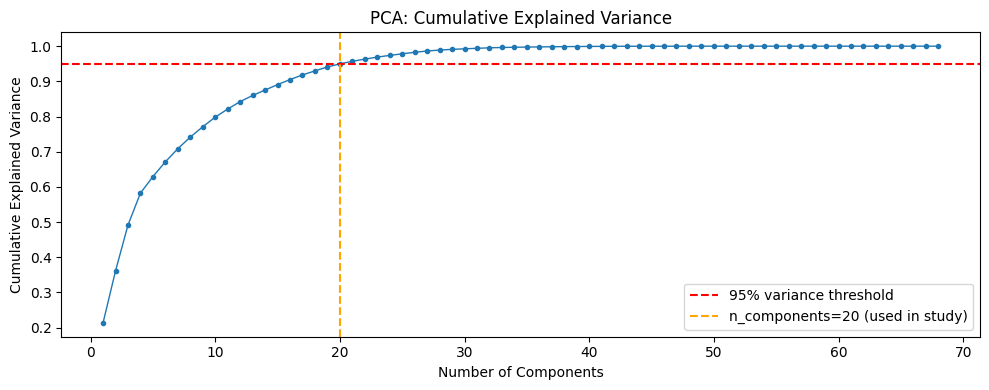

Components needed for 95% variance: 21
Variance retained by 20 components: 0.9496


In [12]:
# Check explained variance to justify n_components choice
pca_check = PCA(random_state=RANDOM_STATE)
pca_check.fit(X_scaled)

cumulative_variance = np.cumsum(pca_check.explained_variance_ratio_)
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.', linewidth=1)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% variance threshold')
plt.axvline(x=20, color='orange', linestyle='--', label='n_components=20 (used in study)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Components needed for 95% variance: {n_95}")
print(f"Variance retained by 20 components: {cumulative_variance[19]:.4f}")

In [13]:
# Apply PCA with n_components=20
pca = PCA(n_components=20, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"Shape after PCA: {X_pca.shape}")

Shape after PCA: (223108, 20)


---
## 6. Train/Test Split
The PCA-reduced feature matrix is split into 80% training and 20% test sets using stratified sampling to preserve class proportions. `random_state=42` ensures reproducibility.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"\nTraining class balance:\n{y_train.value_counts()}")

Training set: 178,486 samples
Test set:     44,622 samples

Training class balance:
Label
1    102413
0     76073
Name: count, dtype: int64


---
## 7. Model Training
Three classifiers are trained on the preprocessed, PCA-reduced training data:
- **Decision Tree:** Simple, interpretable, single-tree classifier
- **Random Forest:** Ensemble of 100 trees using bagging to reduce variance
- **XGBoost:** Gradient boosting with iterative error correction

All models use `random_state=42` for reproducibility.

In [15]:
# Decision Tree
print("Training Decision Tree...")
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
print("Done.")

Training Decision Tree...
Done.


In [16]:
# Random Forest
print("Training Random Forest (100 estimators)...")
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
print("Done.")

Training Random Forest (100 estimators)...
Done.


In [17]:
# XGBoost
print("Training XGBoost...")
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
xgb.fit(X_train, y_train)
print("Done.")

Training XGBoost...
Done.


---
## 8. Model Evaluation
Each model is evaluated on the held-out test set using:
- **Accuracy** — overall correct classification rate
- **Classification Report** — per-class precision, recall, F1-score
- **Confusion Matrix** — breakdown of true/false positives and negatives
- **ROC-AUC Score** — discriminative ability across classification thresholds

In [18]:
def evaluate_model(model, name="Model"):
    """Evaluate a trained classifier on the test set and print all metrics."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {acc:.6f}")
    print(f"ROC-AUC:   {roc:.6f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'DDoS']))
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    tn, fp, fn, tp = cm.ravel()
    print(f"  True Negatives (Benign correctly identified): {tn:,}")
    print(f"  False Positives (Benign flagged as DDoS):     {fp:,}")
    print(f"  False Negatives (DDoS missed):                {fn:,}")
    print(f"  True Positives (DDoS correctly detected):     {tp:,}")
    print()

In [19]:
evaluate_model(dt, "Decision Tree")

  Decision Tree
Accuracy:  0.999507
ROC-AUC:   0.999530

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     19019
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     44622
   macro avg       1.00      1.00      1.00     44622
weighted avg       1.00      1.00      1.00     44622

Confusion Matrix:
[[19013     6]
 [   16 25587]]
  True Negatives (Benign correctly identified): 19,013
  False Positives (Benign flagged as DDoS):     6
  False Negatives (DDoS missed):                16
  True Positives (DDoS correctly detected):     25,587



In [20]:
evaluate_model(rf, "Random Forest")

  Random Forest
Accuracy:  0.999798
ROC-AUC:   0.999939

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     19019
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     44622
   macro avg       1.00      1.00      1.00     44622
weighted avg       1.00      1.00      1.00     44622

Confusion Matrix:
[[19018     1]
 [    8 25595]]
  True Negatives (Benign correctly identified): 19,018
  False Positives (Benign flagged as DDoS):     1
  False Negatives (DDoS missed):                8
  True Positives (DDoS correctly detected):     25,595



In [21]:
evaluate_model(xgb, "XGBoost")

  XGBoost
Accuracy:  0.999798
ROC-AUC:   0.999976

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     19019
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     44622
   macro avg       1.00      1.00      1.00     44622
weighted avg       1.00      1.00      1.00     44622

Confusion Matrix:
[[19017     2]
 [    7 25596]]
  True Negatives (Benign correctly identified): 19,017
  False Positives (Benign flagged as DDoS):     2
  False Negatives (DDoS missed):                7
  True Positives (DDoS correctly detected):     25,596



---
## 9. Comparative Summary
A side-by-side summary of all three models across key metrics.

In [22]:
models = {
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 6),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 6),
        'False Positives': fp,
        'False Negatives': fn
    })

summary_df = pd.DataFrame(results).set_index('Model')
print(summary_df.to_string())

               Accuracy   ROC-AUC  False Positives  False Negatives
Model                                                              
Decision Tree  0.999507  0.999530                6               16
Random Forest  0.999798  0.999939                1                8
XGBoost        0.999798  0.999976                2                7


---
## 10. Feature Importance Analysis
Random Forest provides feature importance scores indicating how much each feature contributed to classification decisions. Since PCA transforms the feature space into principal components, we also show the original feature loadings to identify which raw network traffic attributes are most discriminative.

> Note: Feature importance here refers to the PCA components. To map back to original features, we inspect PCA component loadings.

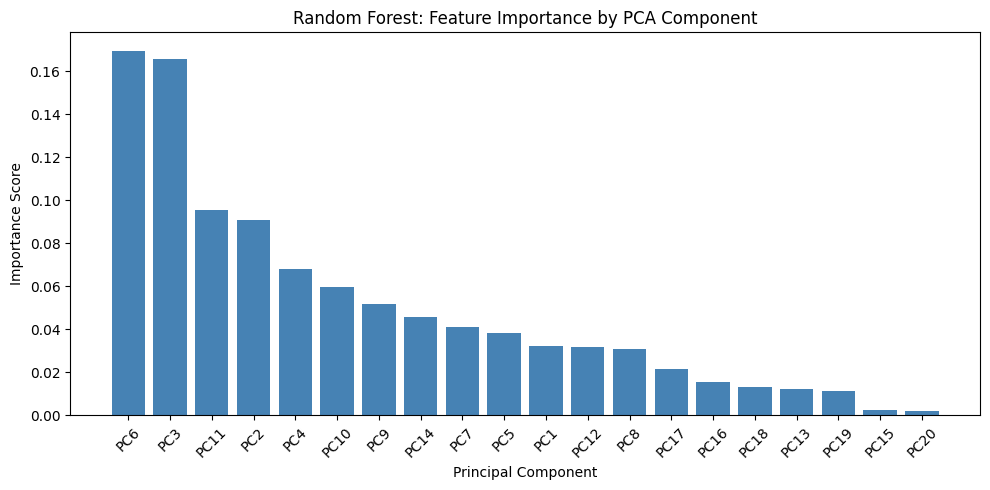

In [23]:
# Feature importance from Random Forest (on PCA components)
importances = rf.feature_importances_
top_n = 20
top_idx = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(top_n), importances[top_idx], color='steelblue')
plt.xticks(range(top_n), [f'PC{i+1}' for i in top_idx], rotation=45)
plt.xlabel('Principal Component')
plt.ylabel('Importance Score')
plt.title('Random Forest: Feature Importance by PCA Component')
plt.tight_layout()
plt.show()

Top 15 original features contributing to PC6 (most important component):
SYN Flag Count                 0.430427
Fwd PSH Flags                  0.430427
Fwd Packet Length Min          0.372376
Down/Up Ratio                  0.271098
URG Flag Count                 0.186793
Fwd Packets/s                  0.184719
Flow Packets/s                 0.183925
Fwd Packet Length Std          0.159467
Bwd IAT Min                    0.146313
Total Length of Fwd Packets    0.143652
Subflow Fwd Bytes              0.143652
ACK Flag Count                 0.133537
Fwd IAT Min                    0.128834
Fwd Packet Length Max          0.128330
Min Packet Length              0.128240


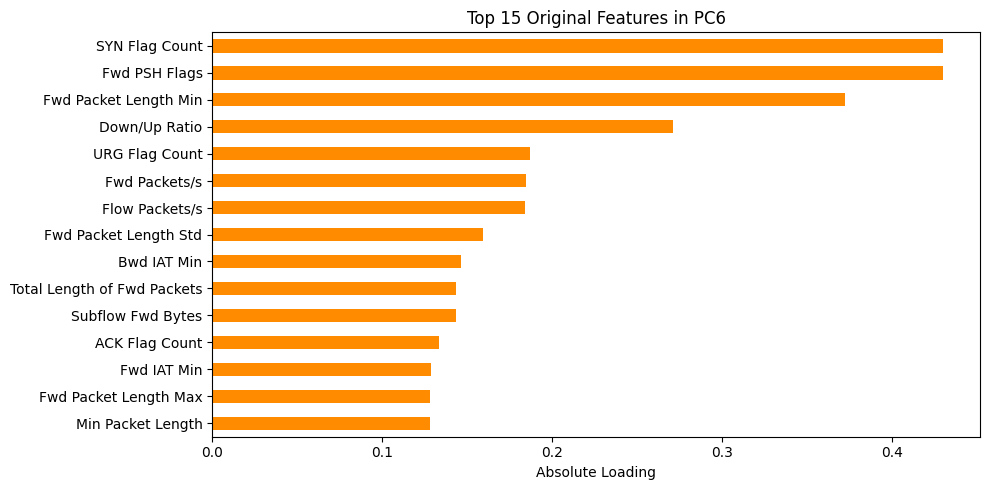

In [24]:
# Map top PCA components back to original features via loadings
# The most important PC's top contributing original features
top_pc = top_idx[0]  # most important principal component
loadings = pd.Series(
    np.abs(pca.components_[top_pc]),
    index=selected_feature_names
).sort_values(ascending=False)

print(f"Top 15 original features contributing to PC{top_pc+1} (most important component):")
print(loadings.head(15).to_string())

# Plot
plt.figure(figsize=(10, 5))
loadings.head(15).plot(kind='barh', color='darkorange')
plt.xlabel('Absolute Loading')
plt.title(f'Top 15 Original Features in PC{top_pc+1}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## Summary of Changes from Original Notebook

| Issue | Fix Applied |
|---|---|
| PCA computed but X_scaled used for training | X_pca now used in train/test split |
| SMOTE imported but never used | Removed from imports |
| SVC imported but never used | Removed from imports |
| ROC-AUC only computed for Random Forest | Added to evaluate_model() for all models |
| No random_state on Decision Tree or Random Forest | random_state=42 added to all models |
| Feature importance plot had no axis labels | Named PCA components on x-axis + loading plot added |
| PCA explained variance never checked | Cumulative variance plot added before applying PCA |
| No markdown documentation | Full section headers and explanations added |
| No README/intro cell | Title cell with dataset source and run instructions added |
| Feature names lost after VarianceThreshold | feature_names saved before transformation and used in loading analysis |